In [1]:
import sys
import os
import pandas as pd
import importlib

# Proje kök dizinini Python arama yolunda en üste al
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root) # Proje kök dizinini arama yolunun en üstüne ekleyelim

# utils.py içindeki fonksiyonları import edelim
import src.utils as utils
importlib.reload(utils) # utils modülünü yeniden yükleyelim, böylece yapılan değişiklikler geçerli olur
chronogical_split = utils.chronogical_split

# EDA aşamasındaki veriyi yükleyelim
data_path = '../data/processed/nrel_data_5cities_filtered.parquet'
print(f"Veri dosyası: {data_path}...")
df = pd.read_parquet(data_path)
print(f"Veri başarıyla yüklendi. Toplam kayıt sayısı: {len(df)}")

# Kronolojik olarak veriyi bölerek eğitim ve test setlerini oluşturalım
train_df, val_df, test_df = chronogical_split(df, datetime_col ='datetime')

# 4. TEST VE SAĞLAMALAR (Hata yapıp yapmadığımızı buradan göreceğiz)
print("\n--- Veri Bölünme Raporu ---")
print(f"Eğitim Seti (Train) : {len(train_df):,} satır | Başlangıç: {train_df.index.min()} | Bitiş: {train_df.index.max()}")
print(f"Doğrulama Seti (Val): {len(val_df):,} satır  | Başlangıç: {val_df.index.min()} | Bitiş: {val_df.index.max()}")
print(f"Test Seti (Test)    : {len(test_df):,} satır  | Başlangıç: {test_df.index.min()} | Bitiş: {test_df.index.max()}")

# Şehir bazında dağılım kontrolü
print("\n--- Eğitim Setindeki Şehir Dağılımı ---")
print(train_df['City'].value_counts())

Veri dosyası: ../data/processed/nrel_data_5cities_filtered.parquet...
Veri başarıyla yüklendi. Toplam kayıt sayısı: 221516

--- Veri Bölünme Raporu ---
Eğitim Seti (Train) : 132,912 satır | Başlangıç: 0 | Bitiş: 132911
Doğrulama Seti (Val): 44,312 satır  | Başlangıç: 0 | Bitiş: 44311
Test Seti (Test)    : 44,292 satır  | Başlangıç: 0 | Bitiş: 44291

--- Eğitim Setindeki Şehir Dağılımı ---
City
Seattle_WA    26743
Boston_MA     26601
Phoenix_AZ    26567
Denver_CO     26555
Miami_FL      26446
Name: count, dtype: int64


In [2]:
import src.utils as utils
importlib.reload(utils) # utils.py içindeki yeni fonksiyonu algılasın

# Modelin kullanacağı özellikleri ve hedefi belirleyelim
TARGET_COL = 'GHI_Filtered' # Hedef değişkenimiz GHI_Filtered olacak
FEATURE_COLS = [
    'GHI_Filtered', 'Solar Zenith Angle', 'Temperature', 
    'Relative Humidity', 'Wind Speed', 'Cloud Type', 
    'Clearness_Index', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]

# 96 adım geçmişine bak (48 saat), 24 adım geleceği tahmin et (12 saat)
LOOK_BACK = 96
LOOK_FORWARD = 24

print("1. Eğitim (Train) seti hazırlanıyor...")
X_train, y_train = utils.create_sliding_features(train_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Train seti hazırlandı. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print("\n2. Doğrulama (Validation) seti hazırlanıyor...")
X_val, y_val = utils.create_sliding_features(val_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Validation seti hazırlandı. X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print("\n3. Test seti hazırlanıyor...")
X_test, y_test = utils.create_sliding_features(test_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Test seti hazırlandı. X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

1. Eğitim (Train) seti hazırlanıyor...
Train seti hazırlandı. X_train shape: (132317, 96, 11), y_train shape: (132317, 24)

2. Doğrulama (Validation) seti hazırlanıyor...
Validation seti hazırlandı. X_val shape: (43717, 96, 11), y_val shape: (43717, 24)

3. Test seti hazırlanıyor...
Test seti hazırlandı. X_test shape: (43697, 96, 11), y_test shape: (43697, 24)


In [3]:
import torch
from torch.utils.data import TensorDataset, DataLoader

print("\n--- Numpy Dizisinden Tensörler oluşturuluyor ---")
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Batch size yani tanımlayalım
BATCH_SIZE = 128

print("\n--- DataLoader'lar oluşturuluyor ---")
# Eğitim seti için Shuffle = True yaparak veriyi karıştıralım ki ezberlemeyi önleyelim
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Doğrulama ve test setleri için Shuffle = False yaparak sıralı kalmasını sağlayalım
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train DataLoader: {len(train_loader)} batch")
print(f"Validation DataLoader: {len(val_loader)} batch")
print(f"Test DataLoader: {len(test_loader)} batch")


--- Numpy Dizisinden Tensörler oluşturuluyor ---

--- DataLoader'lar oluşturuluyor ---
Train DataLoader: 1034 batch
Validation DataLoader: 342 batch
Test DataLoader: 342 batch


# Autoformer Eğitimi ve Analizi

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
import importlib

# Cihaz Seçimi (GPU varsa kullan, yoksa CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Model eğitimi için cihaz: {device.type.upper()}")

# Modeli oluşturma
import src.models.autoformer as autoformer_module
importlib.reload(autoformer_module) # Dosyayı RAM'den silip baştan okur!
from src.models.autoformer import CustomAutoFormer

# Paraöetreler: 96 adım geçmiş (Look-back), 24 adım gelecek (Horizon), 11 özellik (Feature sayısı)
model = CustomAutoFormer(seq_len=96, pred_len=24,enc_in=11).to(device)

# Ceza ve Ödül Fonksiyonları
criterion = nn.MSELoss() # Kayıp fonksiyonu olarak Ortalama Kare Hata (MSE: Tahminle Gerçek arasındaki fark) kullanacağız
optimizer = optim.Adam(model.parameters(), lr=0.001) # Optimizasyon algoritması olarak Adam kullanacağız (Öğrenme hızı: 0.001)

# Eğitim Döngüsü
EPOCHS = 15 # Eğitim süresini 15 epoch ile sınırlayalım, bu sayede hızlıca sonuç alabiliriz
train_losses = []
val_losses = []

print("\n--- Model Eğitimi Başlıyor ---")
for epoch in range(EPOCHS):
    start_time = time.time() # Her epoch'un başlangıcında zamanı kaydedelim
    model.train()
    total_train_loss = 0

    for batch_X, batch_y in train_loader:
        # Veriyi cihazımıza taşıyalım
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad() # Önceki adımın gradyanlarını sıfırlayalım
        outputs = model(batch_X) # Modelden tahminler alalım

        loss = criterion(outputs, batch_y) # Kayıp fonksiyonunu hesaplayalım
        loss.backward() # Gradyanları hesaplayalım
        optimizer.step() # Model parametrelerini güncelleyelim

        total_train_loss += loss.item() # Toplam kaybı güncelleyelim
    
    avg_train_loss = total_train_loss / len(train_loader) # Ortalama eğitim kaybını hesaplayalım
    train_losses.append(avg_train_loss) # Eğitim kaybını listeye ekleyelim

    model.eval() # Modeli değerlendirme moduna alalım (öğrenme kapalı)
    total_val_loss = 0

    with torch.no_grad(): # Değerlendirme sırasında gradyan hesaplamayı kapatalım
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader) # Ortalama doğrulama kaybını hesaplayalım
    val_losses.append(avg_val_loss) # Doğrulama kaybını listeye ekleyelim

    elapsed_time = time.time() - start_time # Geçen süreyi hesaplayalım
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Time: {elapsed_time:.2f} seconds")

# Modeli kaydetme
os.makedirs('../outputs/models', exist_ok=True)
model_save_path = '../outputs/models/autoformer_solar_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f" Eğitilmiş model kaydedildi: {model_save_path}")

Model eğitimi için cihaz: MPS

--- Model Eğitimi Başlıyor ---
Epoch [1/15] - Train Loss: 44326.0092 - Val Loss: 34582.5383 - Time: 4.71 seconds
Epoch [2/15] - Train Loss: 32594.7264 - Val Loss: 33362.0923 - Time: 3.94 seconds
Epoch [3/15] - Train Loss: 31731.2941 - Val Loss: 32704.8703 - Time: 4.44 seconds
Epoch [4/15] - Train Loss: 31177.6294 - Val Loss: 32186.5789 - Time: 4.86 seconds
Epoch [5/15] - Train Loss: 30817.6779 - Val Loss: 31899.1642 - Time: 5.08 seconds
Epoch [6/15] - Train Loss: 30601.6016 - Val Loss: 31789.1512 - Time: 4.96 seconds
Epoch [7/15] - Train Loss: 30455.7738 - Val Loss: 31533.7672 - Time: 5.17 seconds
Epoch [8/15] - Train Loss: 30327.5934 - Val Loss: 31438.4103 - Time: 5.08 seconds
Epoch [9/15] - Train Loss: 30215.2358 - Val Loss: 31323.7430 - Time: 4.64 seconds
Epoch [10/15] - Train Loss: 30124.2007 - Val Loss: 31213.9944 - Time: 4.58 seconds
Epoch [11/15] - Train Loss: 30015.1137 - Val Loss: 31113.5449 - Time: 5.00 seconds
Epoch [12/15] - Train Loss: 29902.

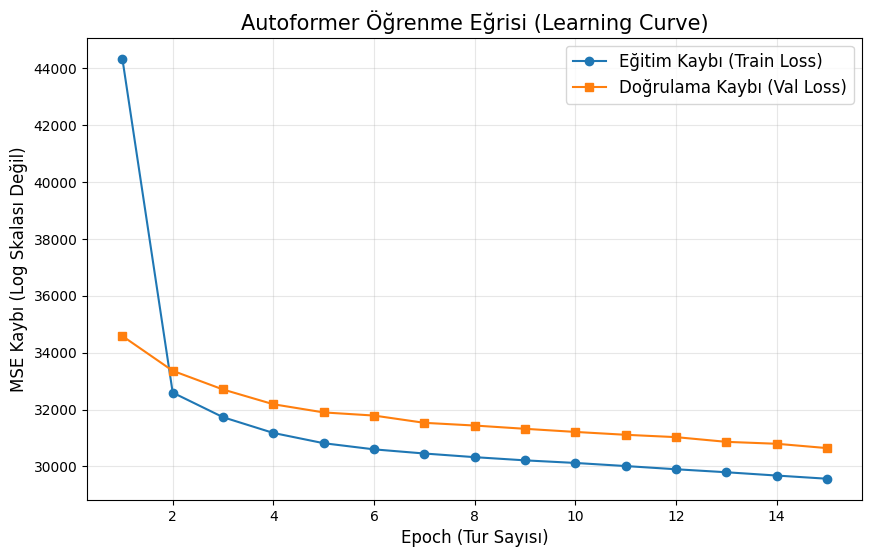

In [5]:
import matplotlib.pyplot as plt
import os

# 1. Eğitim Eğrisi (Learning Curve) Çizimi
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Eğitim Kaybı (Train Loss)', color='#1f77b4', marker='o')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Doğrulama Kaybı (Val Loss)', color='#ff7f0e', marker='s')

plt.title('Autoformer Öğrenme Eğrisi (Learning Curve)', fontsize=15)
plt.xlabel('Epoch (Tur Sayısı)', fontsize=12)
plt.ylabel('MSE Kaybı (Log Skalası Değil)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Çıktıyı plots klasörüne kaydet
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/autoformer_learning_curve.pdf', bbox_inches='tight')
plt.show()

1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...
2. Metrikler Hesaplanıyor...

 TEST SETİ KARNESİ (2024)
---------------------------------
RMSE (Kök Ortalama Kare Hata) : 171.34 W/m²
MAE  (Ortalama Mutlak Hata)   : 135.35 W/m²
MSE  (Ortalama Kare Hata)     : 29358.80

3. Örnek Bir Zaman Dilimi Çizdiriliyor...


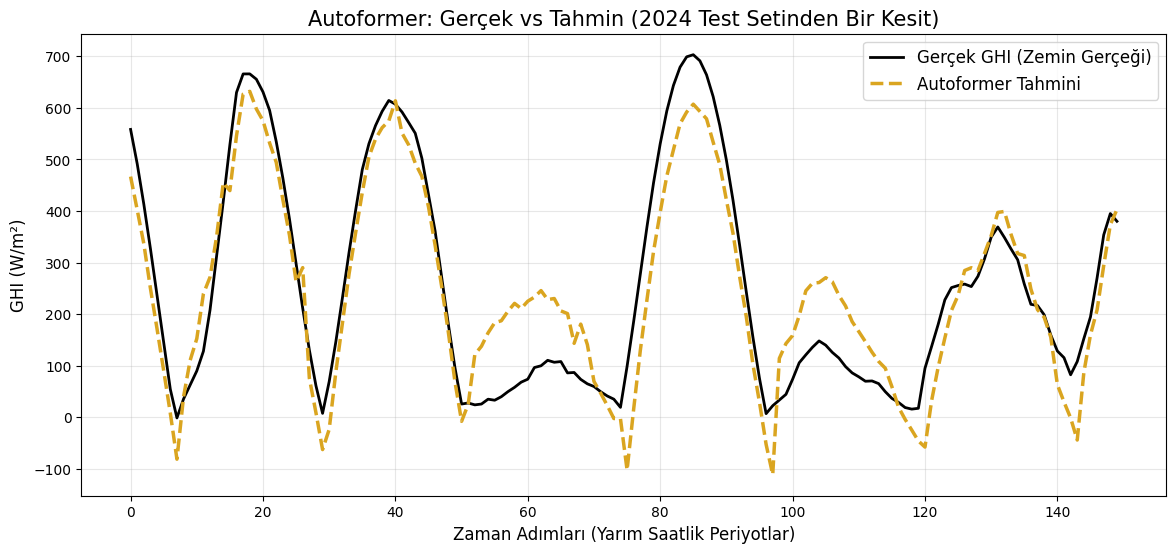

In [6]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("1. Test Seti Üzerinde Tahminler Yapılıyor (2024 Verisi)...")
model.eval() # Modeli sınav moduna al (dropout vs kapatılır)

all_predictions = []
all_trues = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Tahmin yap
        outputs = model(batch_X)
        
        # CPU'ya çek ve numpy array'e çevir
        all_predictions.append(outputs.cpu().numpy())
        all_trues.append(batch_y.cpu().numpy())

# Bütün batch'leri tek bir uzun listeye birleştir
all_predictions = np.concatenate(all_predictions, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

print("2. Metrikler Hesaplanıyor...")
# Sadece ilk tahmin adımını (t+1) değil, tüm 24 adımlık (12 saat) ufku değerlendiriyoruz
mse = mean_squared_error(all_trues, all_predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_trues, all_predictions)

print(f"\n TEST SETİ KARNESİ (2024)")
print(f"---------------------------------")
print(f"RMSE (Kök Ortalama Kare Hata) : {rmse:.2f} W/m²")
print(f"MAE  (Ortalama Mutlak Hata)   : {mae:.2f} W/m²")
print(f"MSE  (Ortalama Kare Hata)     : {mse:.2f}")

# ==========================================
# 3. GÖRSELLEŞTİRME (Gerçek Hava vs Model)
# ==========================================
print("\n3. Örnek Bir Zaman Dilimi Çizdiriliyor...")

# Test setinin içinden rastgele/ardışık 200 adımlık (100 saatlik) bir kesit alalım
# Not: create_sliding_windows'ta shuffle yapmadığımız için bu kesit kronolojiktir
START_IDX = 1000  # İstersen bu sayıyı değiştirip farklı günlere bakabilirsin
WINDOW_SIZE = 150 # Kaç adımı (yarım saati) çizeceğimiz

# Tahminlerin sadece ilk ufuk adımını (t+1) alarak sürekli bir çizgi oluşturalım
true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, 0]
pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, 0]

plt.figure(figsize=(14, 6))
plt.plot(true_line, label='Gerçek GHI (Zemin Gerçeği)', color='black', linewidth=2)
plt.plot(pred_line, label='Autoformer Tahmini', color='#DAA520', linewidth=2.5, linestyle='--')

plt.title('Autoformer: Gerçek vs Tahmin (2024 Test Setinden Bir Kesit)', fontsize=15)
plt.xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Çıktıyı kaydet
plt.savefig('../outputs/plots/autoformer_test_predictions.pdf', bbox_inches='tight')
plt.show()

⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...

Hedef: 30 Dakika (t+1) -> RMSE: 73.15 W/m² | MAE: 58.57 W/m²
Hedef: 3 Saat (t+6) -> RMSE: 162.13 W/m² | MAE: 129.38 W/m²
Hedef: 6 Saat (t+12) -> RMSE: 179.42 W/m² | MAE: 144.11 W/m²
Hedef: 12 Saat (t+24) -> RMSE: 193.28 W/m² | MAE: 157.06 W/m²


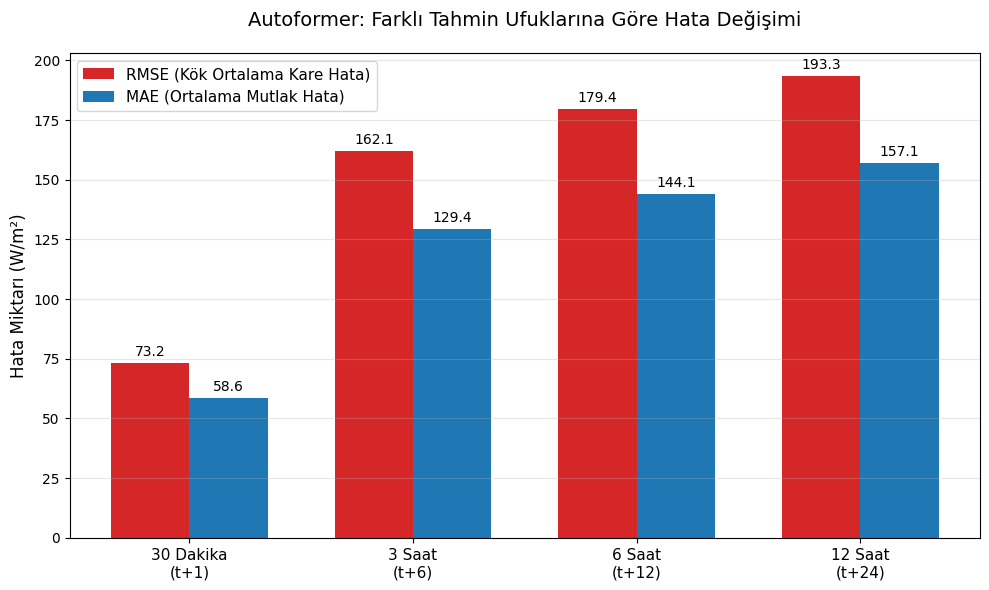

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("⏳ Farklı Zaman Ufukları (Short-term vs Long-term) Analiz Ediliyor...\n")

# İncelemek istediğimiz adımlar: 1. adım (30dk), 6. adım (3 Saat), 12. adım (6 Saat), 24. adım (12 Saat)
horizons = [1, 6, 12, 24]
horizon_labels = ['30 Dakika\n(t+1)', '3 Saat\n(t+6)', '6 Saat\n(t+12)', '12 Saat\n(t+24)']

rmse_list = []
mae_list = []

# Her bir ufuk için sadece o sütunu alıp hatasını hesaplıyoruz
for h in horizons:
    idx = h - 1  # Python 0'dan başladığı için 1. adımın indeksi 0'dır
    
    true_h = all_trues[:, idx]
    pred_h = all_predictions[:, idx]
    
    rmse_h = np.sqrt(mean_squared_error(true_h, pred_h))
    mae_h = mean_absolute_error(true_h, pred_h)
    
    rmse_list.append(rmse_h)
    mae_list.append(mae_h)
    
    label = horizon_labels[horizons.index(h)].replace("\n", " ")
    print(f"Hedef: {label} -> RMSE: {rmse_h:.2f} W/m² | MAE: {mae_h:.2f} W/m²")

# ==========================================
# 📊 MAKALE KALİTESİNDE GRAFİK ÇİZİMİ
# ==========================================
x = np.arange(len(horizons))
width = 0.35  # Sütun genişliği

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rmse_list, width, label='RMSE (Kök Ortalama Kare Hata)', color='#d62728')
rects2 = ax.bar(x + width/2, mae_list, width, label='MAE (Ortalama Mutlak Hata)', color='#1f77b4')

# Eksen ayarları ve İsimlendirmeler
ax.set_ylabel('Hata Miktarı (W/m²)', fontsize=12)
ax.set_title('Autoformer: Farklı Tahmin Ufuklarına Göre Hata Değişimi', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(horizon_labels, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Barların tepesine değerleri yazdırma (Daha profesyonel görünüm için)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.savefig('../outputs/plots/autoformer_horizon_degradation.pdf')
plt.show()

📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...


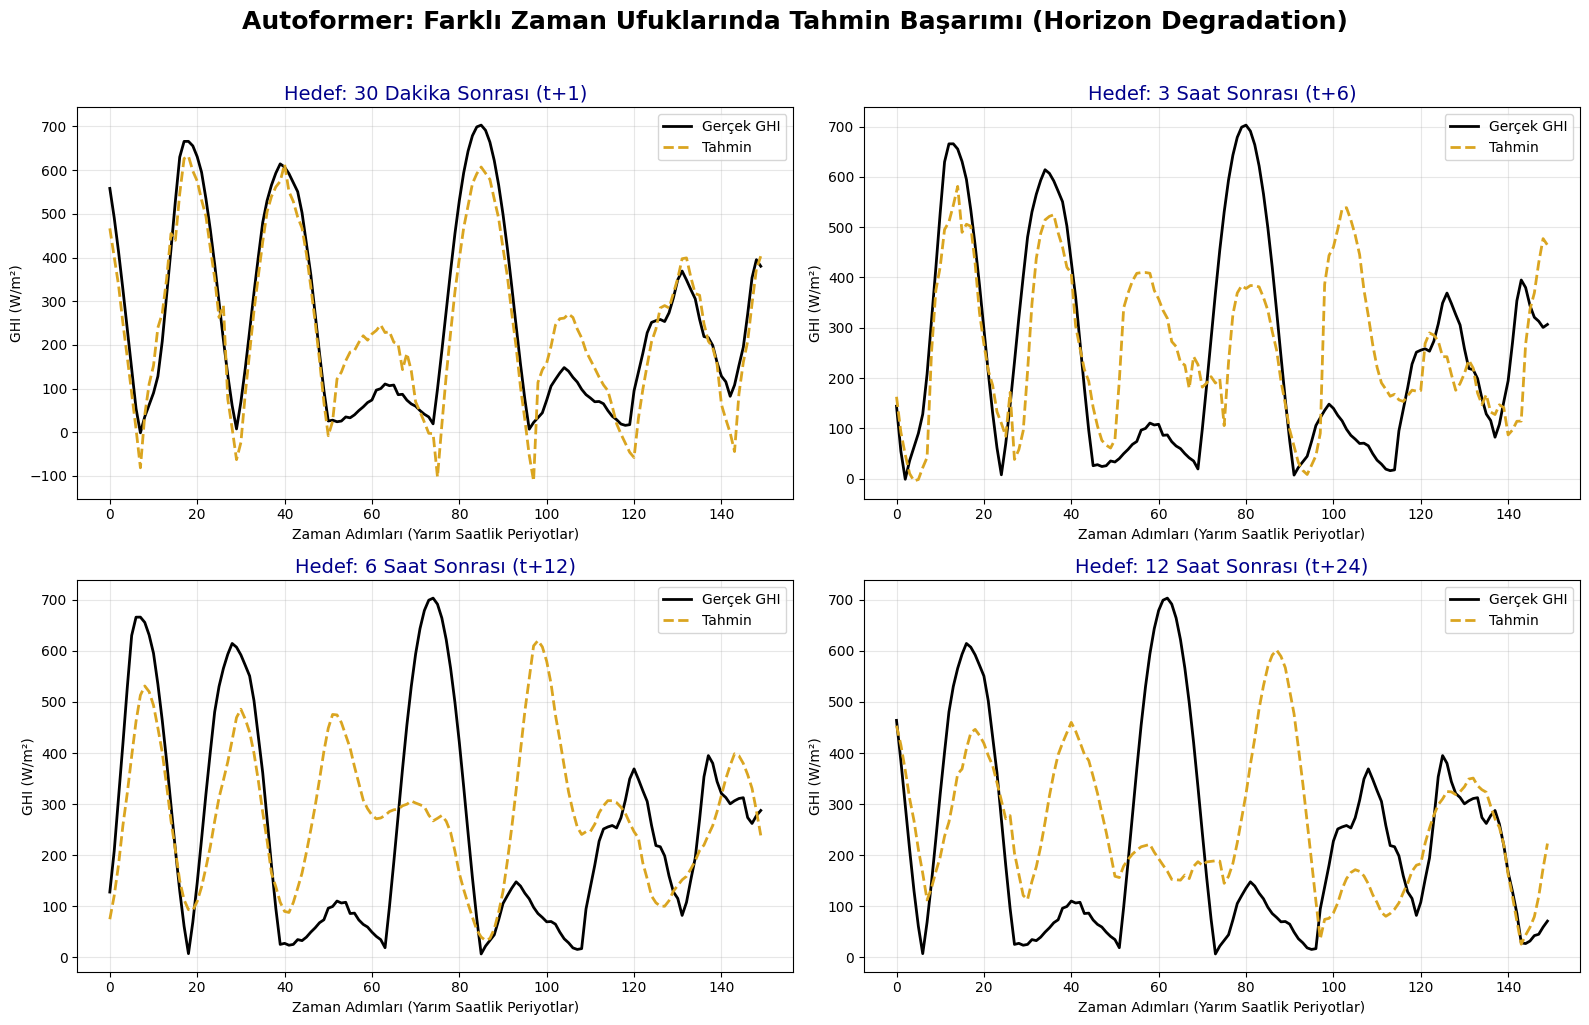

In [8]:
import matplotlib.pyplot as plt

print("📊 Farklı Tahmin Ufukları için Gerçek vs Tahmin Grafikleri Çiziliyor...")

# İnceleyeceğimiz ufuklar ve indeksleri (Python'da indeks 0'dan başladığı için -1 yapıyoruz)
horizons_to_plot = [
    {"step": 1, "name": "30 Dakika Sonrası (t+1)", "idx": 0},
    {"step": 6, "name": "3 Saat Sonrası (t+6)", "idx": 5},
    {"step": 12, "name": "6 Saat Sonrası (t+12)", "idx": 11},
    {"step": 24, "name": "12 Saat Sonrası (t+24)", "idx": 23}
]

# Önceki grafikte kullandığımız aynı zaman aralığını alalım ki kıyaslama adil olsun
START_IDX = 1000
WINDOW_SIZE = 150

# 2x2'lik bir pano (subplot) oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Autoformer: Farklı Zaman Ufuklarında Tahmin Başarımı (Horizon Degradation)', fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten() # 2x2'lik matrisi düz bir listeye çevir (Döngüde kolaylık için)

for i, h_info in enumerate(horizons_to_plot):
    ax = axes[i]
    idx = h_info["idx"]
    
    # Sadece o ufka (örneğin 3 saat sonrasına) ait tahminleri ve gerçekleri çek
    true_line = all_trues[START_IDX:START_IDX+WINDOW_SIZE, idx]
    pred_line = all_predictions[START_IDX:START_IDX+WINDOW_SIZE, idx]
    
    ax.plot(true_line, label='Gerçek GHI', color='black', linewidth=2)
    ax.plot(pred_line, label='Tahmin', color='#DAA520', linewidth=2, linestyle='--')
    
    ax.set_title(f"Hedef: {h_info['name']}", fontsize=14, color='darkblue')
    ax.set_xlabel('Zaman Adımları (Yarım Saatlik Periyotlar)', fontsize=10)
    ax.set_ylabel('GHI (W/m²)', fontsize=10)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/autoformer_horizon_subplots.pdf', bbox_inches='tight')
plt.show()

🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...



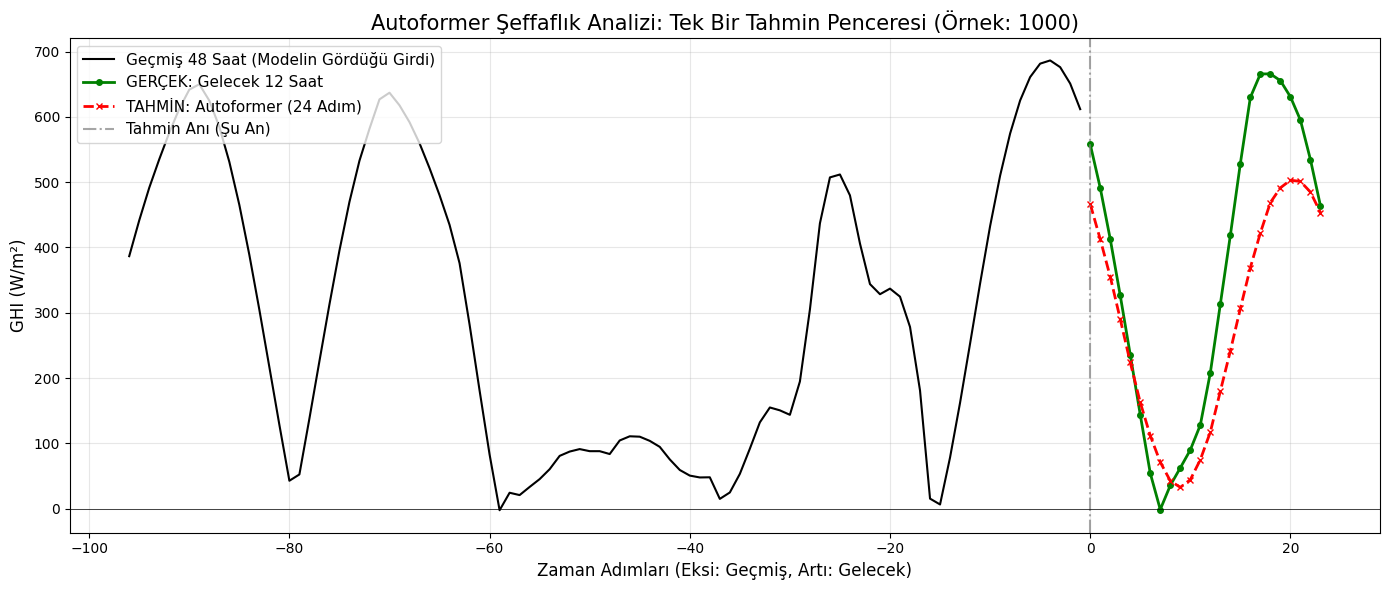

In [9]:
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Şeffaflık Testi: Tek Seferlik 12 Saatlik (24 Adım) Tahmin Penceresi Çiziliyor...\n")

# Rastgele ama manidar bir zaman noktası seçelim (Örneğin test setinin 1000. adımı)
# İstersen bu rakamı 2000, 5000 yapıp farklı günlere de bakabilirsin.
SAMPLE_IDX = 1000

# 1. GEÇMİŞ: Modelin baktığı 96 adımlık geçmişi (X_test'ten) alıyoruz
# X_test boyutu (Örnek Sayısı, 96, 11). GHI_Filtered 0. indekste.
past_ghi = X_test[SAMPLE_IDX, :, 0] 

# 2. GELECEK: 24 adımlık gerçek değer ve modelin tahmini (all_trues ve all_predictions'dan)
true_future = all_trues[SAMPLE_IDX, :]
pred_future = all_predictions[SAMPLE_IDX, :]

# X ekseni (Zaman) ayarları: Geçmişi eksi (-), geleceği artı (+) olarak ayarlayalım
past_time = np.arange(-96, 0)
future_time = np.arange(0, 24)

# ==========================================
# 📊 GRAFİK ÇİZİMİ
# ==========================================
plt.figure(figsize=(14, 6))

# Geçmişi çiz
plt.plot(past_time, past_ghi, label='Geçmiş 48 Saat (Modelin Gördüğü Girdi)', color='black', linewidth=1.5)

# Geleceği çiz (Gerçek vs Tahmin)
plt.plot(future_time, true_future, label='GERÇEK: Gelecek 12 Saat', color='green', linewidth=2, marker='o', markersize=4)
plt.plot(future_time, pred_future, label='TAHMİN: Autoformer (24 Adım)', color='red', linewidth=2, linestyle='--', marker='x', markersize=4)

# Bugünü (0 noktasını) belirten dikey çizgi
plt.axvline(x=0, color='gray', linestyle='-.', alpha=0.7, label='Tahmin Anı (Şu An)')

plt.title(f'Autoformer Şeffaflık Analizi: Tek Bir Tahmin Penceresi (Örnek: {SAMPLE_IDX})', fontsize=15)
plt.xlabel('Zaman Adımları (Eksi: Geçmiş, Artı: Gelecek)', fontsize=12)
plt.ylabel('GHI (W/m²)', fontsize=12)

# X ekseni metinlerini düzenleyelim
plt.axhline(0, color='black', linewidth=0.5)
plt.legend(fontsize=11, loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/autoformer_single_window_forecast.pdf')
plt.show()

# PATCHTST Eğitimi ve Analizi

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
import matplotlib.pyplot as plt
import importlib

# Modeli oluşturma
import src.models.patchtst as patchtst_module
importlib.reload(patchtst_module) # Dosyayı RAM'den silip baştan okur!
from src.models.patchtst import CustomPatchTST


# Cihaz Seçimi (GPU varsa kullan, yoksa CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Model eğitimi için cihaz: {device.type.upper()}")


# Paraöetreler: 96 adım geçmiş (Look-back), 24 adım gelecek (Horizon), 11 özellik (Feature sayısı)
model_patch = CustomPatchTST(seq_len=96, pred_len=24,enc_in=11).to(device)

# Ceza ve Ödül Fonksiyonları
criterion = nn.MSELoss() # Kayıp fonksiyonu olarak Ortalama Kare Hata (MSE: Tahminle Gerçek arasındaki fark) kullanacağız
optimizer = optim.Adam(model_patch.parameters(), lr=0.001) # Optimizasyon algoritması olarak Adam kullanacağız (Öğrenme hızı: 0.001)

# Eğitim Döngüsü
EPOCHS = 15 # Eğitim süresini 15 epoch ile sınırlayalım, bu sayede hızlıca sonuç alabiliriz
train_losses_patch = []
val_losses_patch = []

print("\n--- Model Eğitimi Başlıyor ---")

for epoch in range(EPOCHS):

    start_time = time.time() # Her epoch'un başlangıcında zamanı kaydedelim
    total_train_loss = 0

    for batch_X, batch_y in train_loader:
        # Veriyi cihazımıza taşıyalım
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad() # Önceki adımın gradyanlarını sıfırlayalım
        outputs = model_patch(batch_X) # Modelden tahminler alalım

        loss = criterion(outputs, batch_y) # Kayıp fonksiyonunu hesaplayalım
        loss.backward() # Gradyanları hesaplayalım
        optimizer.step() # Model parametrelerini güncelleyelim

        total_train_loss += loss.item() # Toplam kaybı güncelleyelim
    
    avg_train_loss = total_train_loss / len(train_loader) # Ortalama eğitim kaybını hesaplayalım
    train_losses_patch.append(avg_train_loss) # Eğitim kaybını listeye ekleyelim

    model_patch.eval() # Modeli değerlendirme moduna alalım (öğrenme kapalı)
    total_val_loss = 0

    with torch.no_grad(): # Değerlendirme sırasında gradyan hesaplamayı kapatalım
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model_patch(batch_X)
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader) # Ortalama doğrulama kaybını hesaplayalım
    val_losses_patch.append(avg_val_loss) # Doğrulama kaybını listeye ekleyelim

    elapsed_time = time.time() - start_time # Geçen süreyi hesaplayalım
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Time: {elapsed_time:.2f} seconds")

# Modeli kaydetme
os.makedirs('../outputs/models', exist_ok=True)
model_save_path = '../outputs/models/patchtst_solar_model.pth'
torch.save(model_patch.state_dict(), model_save_path)
print(f" Eğitilmiş model kaydedildi: {model_save_path}")

Model eğitimi için cihaz: MPS

--- Model Eğitimi Başlıyor ---
Epoch [1/15] - Train Loss: 75063.1529 - Val Loss: 32125.8085 - Time: 107.12 seconds
Epoch [2/15] - Train Loss: 21165.6648 - Val Loss: 20902.0226 - Time: 72.51 seconds
Epoch [3/15] - Train Loss: 18075.7799 - Val Loss: 19337.3067 - Time: 82.20 seconds
Epoch [4/15] - Train Loss: 16637.0275 - Val Loss: 17545.1661 - Time: 94.37 seconds
Epoch [5/15] - Train Loss: 15817.1335 - Val Loss: 17111.4969 - Time: 143.56 seconds
Epoch [6/15] - Train Loss: 15270.4296 - Val Loss: 16920.5566 - Time: 80.55 seconds
Epoch [7/15] - Train Loss: 14841.6573 - Val Loss: 16537.2529 - Time: 103.96 seconds
Epoch [8/15] - Train Loss: 14556.2964 - Val Loss: 16639.7224 - Time: 96.40 seconds
Epoch [9/15] - Train Loss: 14324.2906 - Val Loss: 16489.9703 - Time: 93.46 seconds
Epoch [10/15] - Train Loss: 13922.6862 - Val Loss: 16582.8723 - Time: 97.04 seconds
Epoch [11/15] - Train Loss: 13552.7892 - Val Loss: 16515.0833 - Time: 94.83 seconds
Epoch [12/15] - Trai

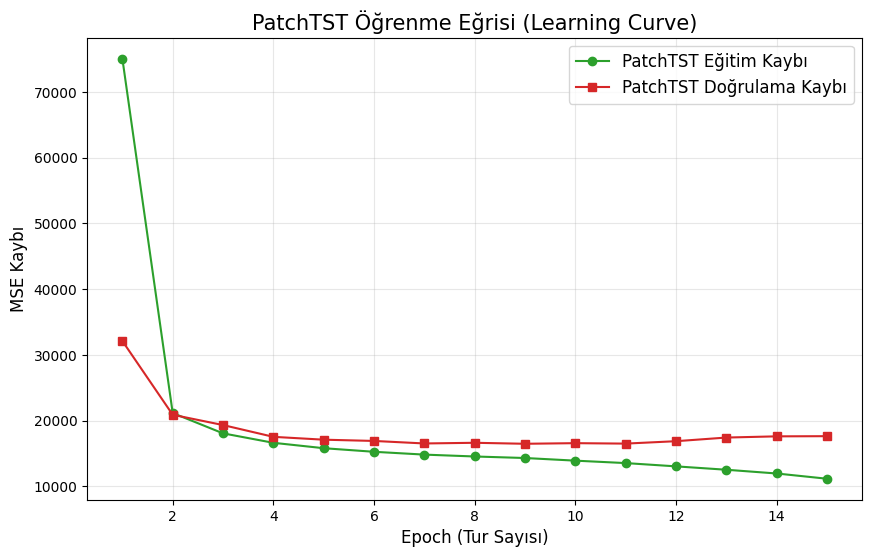

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses_patch, label='PatchTST Eğitim Kaybı', color='#2ca02c', marker='o') # Yeşil renk
plt.plot(range(1, EPOCHS + 1), val_losses_patch, label='PatchTST Doğrulama Kaybı', color='#d62728', marker='s') # Kırmızı renk

plt.title('PatchTST Öğrenme Eğrisi (Learning Curve)', fontsize=15)
plt.xlabel('Epoch (Tur Sayısı)', fontsize=12)
plt.ylabel('MSE Kaybı', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.savefig('../outputs/plots/patchtst_learning_curve.pdf', bbox_inches='tight')
plt.show()